# Supermarket Sales Analysis
---
**Student Name:** Archit Kumar Chaurasiya  
**Project Title:** Supermarket Sales Analysis  
**Dataset:** SUPER MARKET DATA - supermarket_sales_500_rows.csv  

---

## Project Objective

The objective of this project is to perform a comprehensive exploratory data analysis (EDA) on a supermarket sales dataset containing 500 transactions.  
The analysis aims to:
- Understand sales patterns across branches, cities, product categories, and customer segments.
- Identify top-performing product lines, preferred payment methods, and customer behaviour trends.
- Calculate and verify sales figures (Quantity × Unit Price).
- Produce actionable business insights and data-driven recommendations for supermarket management.

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Consistent style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})
sns.set_style('whitegrid')
COLORS = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4','#FF5722','#8BC34A']

print('Libraries imported successfully.')

Libraries imported successfully.


---
## 2. Load Dataset

In [2]:
import pandas as pd

DATA_PATH = '/content/SUPER MARKET DATA - supermarket_sales_500_rows.csv'

df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded successfully.
Shape: 500 rows × 13 columns


In [3]:
# Preview first 5 rows
df.head()

,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.80,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.90,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.40,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.50,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.10,652.85


In [4]:
# Preview last 5 rows
df.tail()

,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
495,INV0496,2026-01-30,B,Delhi,Normal,Male,Tea,Beverages,8,128.86,Net Banking,3.50,1030.88
496,INV0497,2026-05-13,D,Bengaluru,Normal,Female,Eggs,Dairy,4,92.55,Card,4.10,370.20
497,INV0498,2026-05-22,C,Mumbai,Normal,Female,Eggs,Dairy,7,86.94,UPI,4.90,608.58
498,INV0499,2026-02-21,D,Bengaluru,Member,Male,Tea,Beverages,10,117.19,Net Banking,3.50,1171.90
499,INV0500,2026-01-28,B,Delhi,Normal,Female,Face Wash,Personal Care,4,114.37,Cash,3.20,457.48


---
## 3. Initial Dataset Inspection

In [5]:
print('=== Dataset Shape ===')
print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print()
print('=== Column Names ===')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

=== Dataset Shape ===
Rows   : 500
Columns: 13

=== Column Names ===
   1. Invoice ID
   2. Date
   3. Branch
   4. City
   5. Customer Type
   6. Gender
   7. Product
   8. Category
   9. Quantity
  10. Unit Price
  11. Payment
  12. Rating
  13. Sales


In [6]:
# Data types of each column
print('=== Column Data Types ===')
print(df.dtypes)

=== Column Data Types ===
Invoice ID        object
Date              object
Branch            object
City              object
Customer Type     object
Gender            object
Product           object
Category          object
Quantity           int64
Unit Price       float64
Payment           object
Rating           float64
Sales            float64
dtype: object


In [7]:
# Statistical summary of numerical columns
print('=== Statistical Summary (Numerical Columns) ===')
df[['Quantity', 'Unit Price', 'Rating', 'Sales']].describe().round(2)

=== Statistical Summary (Numerical Columns) ===


,Quantity,Unit Price,Rating,Sales
count,500.00,500.00,500.00,500.00
mean,5.54,88.66,3.99,488.82
std,2.88,57.28,0.57,437.33
min,1.00,27.67,3.00,28.61
25%,3.00,43.96,3.50,189.21
50%,5.50,61.88,4.00,335.91
75%,8.00,128.57,4.50,609.88
max,10.00,236.71,5.00,2114.82


---
## 4. Data Quality Assessment

In [8]:
# ── 4.1 Missing Values ──────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values Per Column ===')
print(missing_df)
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values Per Column ===
               Missing Count  Missing %
Invoice ID                 0       0.00
Date                       0       0.00
Branch                     0       0.00
City                       0       0.00
Customer Type              0       0.00
Gender                     0       0.00
Product                    0       0.00
Category                   0       0.00
Quantity                   0       0.00
Unit Price                 0       0.00
Payment                    0       0.00
Rating                     0       0.00
Sales                      0       0.00

Total missing values: 0


In [9]:
# ── 4.2 Duplicate Rows ──────────────────────────────────────────────────────
dup_rows = df.duplicated().sum()
dup_inv  = df['Invoice ID'].duplicated().sum()
print(f'Total fully duplicate rows  : {dup_rows}')
print(f'Duplicate Invoice IDs       : {dup_inv}')

Total fully duplicate rows  : 0
Duplicate Invoice IDs       : 0


In [10]:
# ── 4.3 Unique Values in Categorical Columns ────────────────────────────────
cat_cols = ['Branch', 'City', 'Customer Type', 'Gender', 'Product', 'Category', 'Payment']
print('=== Unique Values in Categorical Columns ===')
for col in cat_cols:
    vals = sorted(df[col].unique())
    print(f'  {col} ({len(vals)} unique): {vals}')

=== Unique Values in Categorical Columns ===
  Branch (4 unique): ['A', 'B', 'C', 'D']
  City (4 unique): ['Bengaluru', 'Delhi', 'Jaipur', 'Mumbai']
  Customer Type (2 unique): ['Member', 'Normal']
  Gender (2 unique): ['Female', 'Male']
  Product (20 unique): ['Apples', 'Bananas', 'Biscuits', 'Bread', 'Cheese', 'Chips', 'Chocolate', 'Coffee', 'Cold Drink', 'Cooking Oil', 'Eggs', 'Face Wash', 'Milk', 'Noodles', 'Potato', 'Rice', 'Shampoo', 'Soap', 'Tea', 'Tomato']
  Category (8 unique): ['Bakery', 'Beverages', 'Dairy', 'Fruits', 'Grocery', 'Personal Care', 'Snacks', 'Vegetables']
  Payment (4 unique): ['Card', 'Cash', 'Net Banking', 'UPI']


In [11]:
# ── 4.4 Numerical Range Validity ────────────────────────────────────────────
print('=== Numerical Range Validity ===')
print(f'  Quantity  <= 0 : {(df["Quantity"] <= 0).sum()} rows')
print(f'  Unit Price <= 0: {(df["Unit Price"] <= 0).sum()} rows')
print(f'  Sales      <= 0: {(df["Sales"] <= 0).sum()} rows')
print(f'  Rating < 1 or > 5: {((df["Rating"] < 1) | (df["Rating"] > 5)).sum()} rows')
print(f'  Quantity range : {df["Quantity"].min()} – {df["Quantity"].max()}')
print(f'  Unit Price range: {df["Unit Price"].min()} – {df["Unit Price"].max()}')
print(f'  Rating range   : {df["Rating"].min()} – {df["Rating"].max()}')

=== Numerical Range Validity ===
  Quantity  <= 0 : 0 rows
  Unit Price <= 0: 0 rows
  Sales      <= 0: 0 rows
  Rating < 1 or > 5: 0 rows
  Quantity range : 1 – 10
  Unit Price range: 27.67 – 236.71
  Rating range   : 3.0 – 5.0


In [12]:
# ── 4.5 Date Column Inspection ──────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'])
print(f'Date range: {df["Date"].min().date()}  →  {df["Date"].max().date()}')
print(f'NaT (unparseable dates): {df["Date"].isnull().sum()}')

Date range: 2026-01-01  →  2026-07-01
NaT (unparseable dates): 0


In [13]:
# ── 4.6 Branch–City Consistency ─────────────────────────────────────────────
print('=== Branch–City Mapping ===')
print(df.groupby(['Branch', 'City']).size().reset_index(name='Transaction Count'))

=== Branch–City Mapping ===
  Branch       City  Transaction Count
0      A     Jaipur                105
1      B      Delhi                133
2      C     Mumbai                143
3      D  Bengaluru                119


In [14]:
# ── 4.7 Product–Category Consistency ────────────────────────────────────────
print('=== Product–Category Mapping ===')
print(df.groupby(['Category', 'Product']).size().reset_index(name='Count').sort_values(['Category','Product']).to_string(index=False))

=== Product–Category Mapping ===
     Category     Product  Count
       Bakery       Bread     28
    Beverages      Coffee     24
    Beverages  Cold Drink     29
    Beverages         Tea     29
        Dairy      Cheese     26
        Dairy        Eggs     20
        Dairy        Milk     22
       Fruits      Apples     20
       Fruits     Bananas     24
      Grocery Cooking Oil     26
      Grocery     Noodles     27
      Grocery        Rice     29
Personal Care   Face Wash     19
Personal Care     Shampoo     27
Personal Care        Soap     27
       Snacks    Biscuits     26
       Snacks       Chips     26
       Snacks   Chocolate     23
   Vegetables      Potato     27
   Vegetables      Tomato     21


In [15]:
# ── 4.8 Sales Column Integrity Check ────────────────────────────────────────
df['Calculated_Sales'] = (df['Quantity'] * df['Unit Price']).round(2)
mismatch = (df['Calculated_Sales'] - df['Sales'].round(2)).abs()
print(f'Max difference between Quantity×Unit Price and Sales column: {mismatch.max()}')
print(f'Rows with Sales mismatch > 0.01                           : {(mismatch > 0.01).sum()}')
# Drop helper column
df.drop(columns=['Calculated_Sales'], inplace=True)
print('\nConclusion: The Sales column is perfectly consistent with Quantity × Unit Price.')

Max difference between Quantity×Unit Price and Sales column: 0.0
Rows with Sales mismatch > 0.01                           : 0

Conclusion: The Sales column is perfectly consistent with Quantity × Unit Price.


### Data Quality Summary

| Check | Result |
|---|---|
| Missing values | ✅ None |
| Fully duplicate rows | ✅ None |
| Duplicate Invoice IDs | ✅ None |
| Negative / zero quantities | ✅ None |
| Negative / zero prices | ✅ None |
| Invalid ratings (outside 1–5) | ✅ None |
| Inconsistent Branch–City mapping | ✅ None — each branch maps to one city |
| Inconsistent Product–Category mapping | ✅ None — each product maps to one category |
| Sales column accuracy | ✅ Exactly equals Quantity × Unit Price |
| Date parsing errors | ✅ None |

**→ No data cleaning or modification is required. The original dataset is fully suitable for analysis.**

---
## 5. Dataset Cleaning Decision

> **CASE A applies: The original dataset is already suitable for analysis.**
>
> No actual data modification was required. The dataset has no missing values, no duplicates, no invalid values, and consistent categorical mappings.
>
> - The analysis is performed **directly from the original dataset**.
> - **No `cleaned_supermarket_sales.csv` file was created.**
> - The original file `SUPER MARKET DATA - supermarket_sales_500_rows.csv` remains **unchanged**.

---
## 6. Sales Calculation (Quantity × Unit Price)

In [16]:
# The Sales column already exists in the dataset and is verified to equal Quantity × Unit Price.
# We use it directly. No new CSV is created — this is an analysis-only operation.

print('Sales Column Verification:')
print(f'  Total Revenue (sum of Sales) : ₹{df["Sales"].sum():,.2f}')
print(f'  Average Sale per Transaction : ₹{df["Sales"].mean():,.2f}')
print(f'  Minimum Sale                 : ₹{df["Sales"].min():,.2f}')
print(f'  Maximum Sale                 : ₹{df["Sales"].max():,.2f}')
print(f'  Median Sale                  : ₹{df["Sales"].median():,.2f}')
print()
print('Sample verification (first 5 rows):')
check = df[['Invoice ID','Quantity','Unit Price','Sales']].head()
check['Qty × Price'] = (check['Quantity'] * check['Unit Price']).round(2)
check['Match'] = check['Sales'].round(2) == check['Qty × Price']
print(check.to_string(index=False))

Sales Column Verification:
  Total Revenue (sum of Sales) : ₹244,411.08
  Average Sale per Transaction : ₹488.82
  Minimum Sale                 : ₹28.61
  Maximum Sale                 : ₹2,114.82
  Median Sale                  : ₹335.91

Sample verification (first 5 rows):
Invoice ID  Quantity  Unit Price  Sales  Qty × Price  Match
   INV0001         4       57.13 228.52       228.52   True
   INV0002         9       66.85 601.65       601.65   True
   INV0003         3       57.28 171.84       171.84   True
   INV0004         2      168.27 336.54       336.54   True
   INV0005         5      130.57 652.85       652.85   True


---
## 7. Feature Engineering (Analysis Support Columns)

In [17]:
# Extract time-based features for analysis (kept in DataFrame only, not saved to CSV)
df['Month']       = df['Date'].dt.month
df['Month_Name']  = df['Date'].dt.strftime('%b')
df['Day_of_Week'] = df['Date'].dt.day_name()

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul']
df['Month_Name'] = pd.Categorical(df['Month_Name'], categories=month_order, ordered=True)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Day_of_Week'] = pd.Categorical(df['Day_of_Week'], categories=day_order, ordered=True)

print('Time-based analysis columns added to DataFrame (in-memory only).')
print(df[['Invoice ID','Date','Month_Name','Day_of_Week']].head())

Time-based analysis columns added to DataFrame (in-memory only).
  Invoice ID       Date Month_Name Day_of_Week
0    INV0001 2026-06-01        Jun      Monday
1    INV0002 2026-02-26        Feb    Thursday
2    INV0003 2026-02-09        Feb      Monday
3    INV0004 2026-01-12        Jan      Monday
4    INV0005 2026-06-30        Jun     Tuesday


---
## 8. Grouped Summaries and Statistics

In [18]:
# ── 8.1 Sales by Branch / City ───────────────────────────────────────────────
branch_sales = df.groupby(['Branch','City']).agg(
    Total_Sales   = ('Sales', 'sum'),
    Transactions  = ('Invoice ID', 'count'),
    Avg_Sale      = ('Sales', 'mean'),
    Total_Qty     = ('Quantity', 'sum'),
    Avg_Rating    = ('Rating', 'mean')
).round(2).reset_index().sort_values('Total_Sales', ascending=False)

print('=== Sales by Branch / City ===')
branch_sales

=== Sales by Branch / City ===


,Branch,City,Total_Sales,Transactions,Avg_Sale,Total_Qty,Avg_Rating
2,C,Mumbai,72469.45,143,506.78,807,4.05
1,B,Delhi,64116.26,133,482.08,692,3.98
3,D,Bengaluru,55468.29,119,466.12,669,4.09
0,A,Jaipur,52357.08,105,498.64,600,3.84


In [19]:
# ── 8.2 Sales by Product Category ───────────────────────────────────────────
cat_sales = df.groupby('Category').agg(
    Total_Sales  = ('Sales', 'sum'),
    Transactions = ('Invoice ID', 'count'),
    Avg_Sale     = ('Sales', 'mean'),
    Total_Qty    = ('Quantity', 'sum'),
    Avg_Rating   = ('Rating', 'mean')
).round(2).reset_index().sort_values('Total_Sales', ascending=False)

print('=== Sales by Product Category ===')
cat_sales

=== Sales by Product Category ===


,Category,Total_Sales,Transactions,Avg_Sale,Total_Qty,Avg_Rating
1,Beverages,56108.24,82,684.25,465,3.96
5,Personal Care,45943.96,73,629.37,399,3.95
2,Dairy,43992.00,68,646.94,345,4.03
4,Grocery,40470.47,82,493.54,439,3.94
3,Fruits,23263.17,44,528.71,223,3.83
6,Snacks,16992.97,75,226.57,443,4.11
7,Vegetables,11124.17,48,231.75,290,3.99
0,Bakery,6516.10,28,232.72,164,4.24


In [20]:
# ── 8.3 Sales by Individual Product ─────────────────────────────────────────
prod_sales = df.groupby('Product').agg(
    Total_Sales  = ('Sales', 'sum'),
    Transactions = ('Invoice ID', 'count'),
    Avg_Sale     = ('Sales', 'mean'),
    Total_Qty    = ('Quantity', 'sum')
).round(2).reset_index().sort_values('Total_Sales', ascending=False)

print('=== Sales by Product (Top 10) ===')
prod_sales.head(10)

=== Sales by Product (Top 10) ===


,Product,Total_Sales,Transactions,Avg_Sale,Total_Qty
4,Cheese,27906.30,26,1073.32,126
7,Coffee,27694.87,24,1153.95,153
16,Shampoo,27497.48,27,1018.43,152
9,Cooking Oil,21525.06,26,827.89,142
18,Tea,17681.59,29,609.71,146
0,Apples,17057.41,20,852.87,119
11,Face Wash,11946.85,19,628.78,100
15,Rice,11754.17,29,405.32,167
8,Cold Drink,10731.78,29,370.06,166
10,Eggs,10429.77,20,521.49,117


In [21]:
# ── 8.4 Sales by Customer Type ──────────────────────────────────────────────
cust_sales = df.groupby('Customer Type').agg(
    Total_Sales  = ('Sales', 'sum'),
    Transactions = ('Invoice ID', 'count'),
    Avg_Sale     = ('Sales', 'mean'),
    Avg_Rating   = ('Rating', 'mean')
).round(2).reset_index()

print('=== Sales by Customer Type ===')
cust_sales

=== Sales by Customer Type ===


,Customer Type,Total_Sales,Transactions,Avg_Sale,Avg_Rating
0,Member,143009.30,296,483.14,4.01
1,Normal,101401.78,204,497.07,3.97


In [22]:
# ── 8.5 Sales by Gender ──────────────────────────────────────────────────────
gender_sales = df.groupby('Gender').agg(
    Total_Sales  = ('Sales', 'sum'),
    Transactions = ('Invoice ID', 'count'),
    Avg_Sale     = ('Sales', 'mean'),
    Avg_Rating   = ('Rating', 'mean')
).round(2).reset_index()

print('=== Sales by Gender ===')
gender_sales

=== Sales by Gender ===


,Gender,Total_Sales,Transactions,Avg_Sale,Avg_Rating
0,Female,123954.12,255,486.09,4.01
1,Male,120456.96,245,491.66,3.98


In [23]:
# ── 8.6 Sales by Payment Method ─────────────────────────────────────────────
pay_sales = df.groupby('Payment').agg(
    Total_Sales  = ('Sales', 'sum'),
    Transactions = ('Invoice ID', 'count'),
    Avg_Sale     = ('Sales', 'mean')
).round(2).reset_index().sort_values('Total_Sales', ascending=False)

print('=== Sales by Payment Method ===')
pay_sales

=== Sales by Payment Method ===


,Payment,Total_Sales,Transactions,Avg_Sale
3,UPI,67910.33,127,534.73
2,Net Banking,65194.93,126,517.42
0,Card,57265.64,125,458.13
1,Cash,54040.18,122,442.95


In [24]:
# ── 8.7 Monthly Sales Trend ──────────────────────────────────────────────────
monthly_sales = df.groupby('Month_Name', observed=True).agg(
    Total_Sales  = ('Sales', 'sum'),
    Transactions = ('Invoice ID', 'count'),
    Avg_Sale     = ('Sales', 'mean')
).round(2).reset_index()

print('=== Monthly Sales Trend ===')
monthly_sales

=== Monthly Sales Trend ===


,Month_Name,Total_Sales,Transactions,Avg_Sale
0,Jan,43415.53,88,493.36
1,Feb,30068.15,65,462.59
2,Mar,37306.42,83,449.47
3,Apr,52569.77,90,584.11
4,May,42542.31,85,500.50
5,Jun,35041.46,82,427.33
6,Jul,3467.44,7,495.35


In [25]:
# ── 8.8 Sales by Day of Week ─────────────────────────────────────────────────
dow_sales = df.groupby('Day_of_Week', observed=True).agg(
    Total_Sales  = ('Sales', 'sum'),
    Transactions = ('Invoice ID', 'count'),
    Avg_Sale     = ('Sales', 'mean')
).round(2).reset_index()

print('=== Sales by Day of Week ===')
dow_sales

=== Sales by Day of Week ===


,Day_of_Week,Total_Sales,Transactions,Avg_Sale
0,Monday,42602.44,77,553.28
1,Tuesday,36293.23,75,483.91
2,Wednesday,34363.73,74,464.37
3,Thursday,28576.26,69,414.15
4,Friday,33026.36,69,478.64
5,Saturday,32829.15,75,437.72
6,Sunday,36719.91,61,601.97


In [26]:
# ── 8.9 Rating Distribution Summary ────────────────────────────────────────
print('=== Rating Distribution ===')
print(df['Rating'].value_counts().sort_index())
print(f'\nOverall Average Rating: {df["Rating"].mean():.2f}')
print()
print('=== Average Rating by Branch ===')
print(df.groupby('Branch')['Rating'].mean().round(2))
print()
print('=== Average Rating by Category ===')
print(df.groupby('Category')['Rating'].mean().sort_values(ascending=False).round(2))

=== Rating Distribution ===
Rating
3.00     8
3.10    24
3.20    33
3.30    24
3.40    24
3.50    31
3.60    25
3.70    14
3.80    28
3.90    23
4.00    28
4.10    30
4.20    25
4.30    30
4.40    14
4.50    33
4.60    26
4.70    20
4.80    23
4.90    21
5.00    16
Name: count, dtype: int64

Overall Average Rating: 3.99

=== Average Rating by Branch ===
Branch
A   3.84
B   3.98
C   4.05
D   4.09
Name: Rating, dtype: float64

=== Average Rating by Category ===
Category
Bakery          4.24
Snacks          4.11
Dairy           4.03
Vegetables      3.99
Beverages       3.96
Personal Care   3.95
Grocery         3.94
Fruits          3.83
Name: Rating, dtype: float64


In [27]:
# ── 8.10 Customer Type × Category Cross-tab ─────────────────────────────────
ct_cross = df.groupby(['Customer Type', 'Category'])['Sales'].sum().unstack(fill_value=0).round(2)
print('=== Total Sales: Customer Type × Category ===')
ct_cross

=== Total Sales: Customer Type × Category ===


Category,Bakery,Beverages,Dairy,Fruits,Grocery,Personal Care,Snacks,Vegetables
Customer Type,,,,,,,,
Member,4247.49,34824.41,19732.80,16463.27,22043.06,29115.42,9066.36,7516.49
Normal,2268.61,21283.83,24259.20,6799.90,18427.41,16828.54,7926.61,3607.68


In [28]:
# ── 8.11 Gender × Category Cross-tab ────────────────────────────────────────
gen_cross = df.groupby(['Gender', 'Category'])['Sales'].sum().unstack(fill_value=0).round(2)
print('=== Total Sales: Gender × Category ===')
gen_cross

=== Total Sales: Gender × Category ===


Category,Bakery,Beverages,Dairy,Fruits,Grocery,Personal Care,Snacks,Vegetables
Gender,,,,,,,,
Female,3452.47,24763.51,23683.89,13511.02,20974.20,23791.00,7114.17,6663.86
Male,3063.63,31344.73,20308.11,9752.15,19496.27,22152.96,9878.80,4460.31


---
## 9. Visualizations

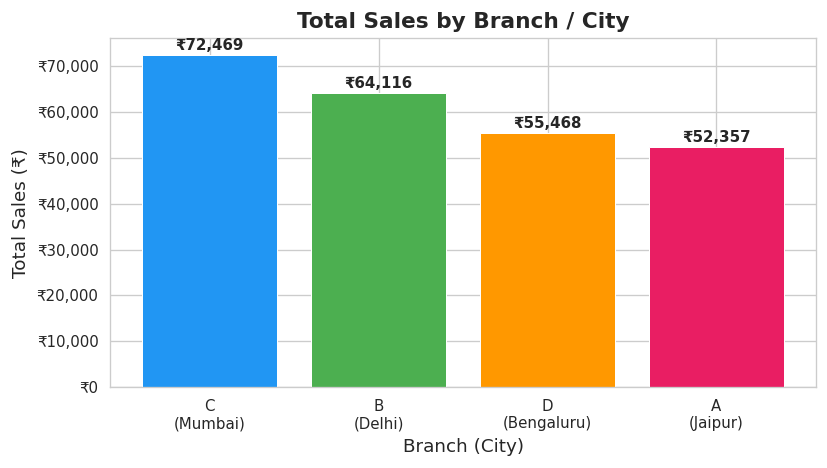

In [29]:
# ── Chart 1: Total Sales by Branch ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    branch_sales['Branch'] + '\n(' + branch_sales['City'] + ')',
    branch_sales['Total_Sales'],
    color=COLORS[:4], edgecolor='white', linewidth=0.6
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Total Sales by Branch / City', fontweight='bold')
ax.set_xlabel('Branch (City)')
ax.set_ylabel('Total Sales (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.tight_layout()
plt.show()

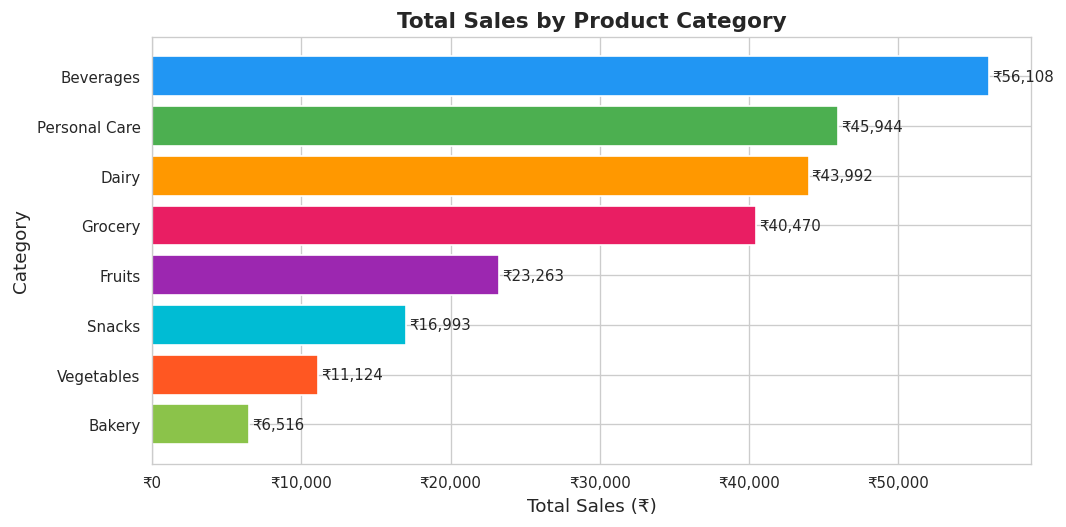

In [30]:
# ── Chart 2: Total Sales by Product Category ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(cat_sales['Category'], cat_sales['Total_Sales'],
               color=COLORS[:len(cat_sales)], edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'₹{bar.get_width():,.0f}', va='center', fontsize=9)
ax.set_title('Total Sales by Product Category', fontweight='bold')
ax.set_xlabel('Total Sales (₹)')
ax.set_ylabel('Category')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.tight_layout()
plt.show()

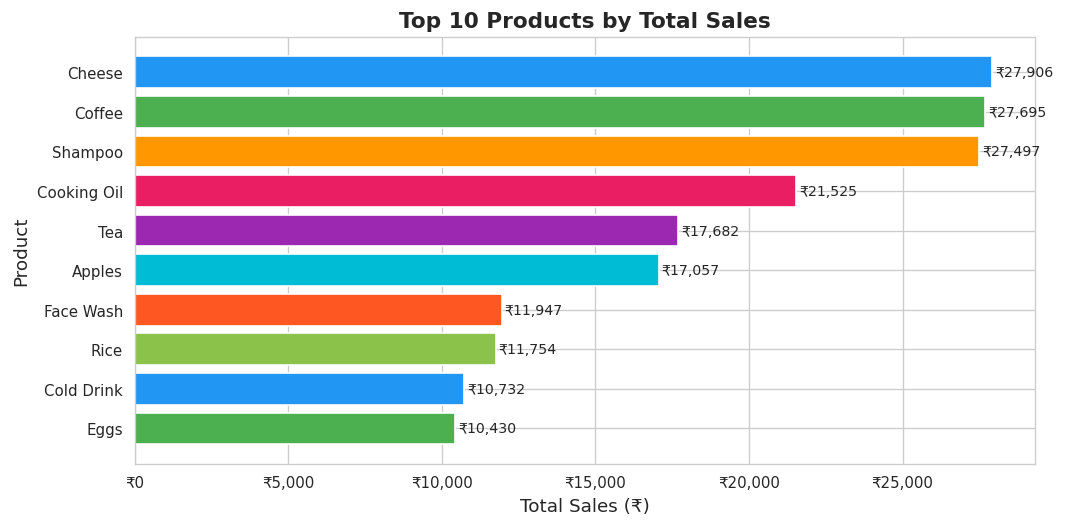

In [31]:
# ── Chart 3: Top 10 Products by Total Sales ──────────────────────────────────
top10 = prod_sales.head(10)
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(top10['Product'], top10['Total_Sales'],
               color=COLORS[:len(top10)], edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'₹{bar.get_width():,.0f}', va='center', fontsize=8.5)
ax.set_title('Top 10 Products by Total Sales', fontweight='bold')
ax.set_xlabel('Total Sales (₹)')
ax.set_ylabel('Product')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.tight_layout()
plt.show()

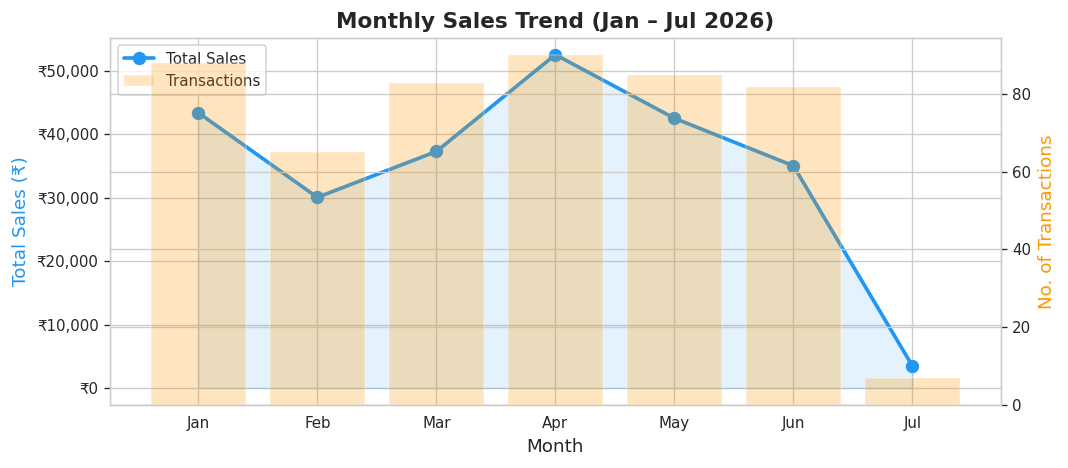

In [32]:
# ── Chart 4: Monthly Sales Trend (Line Chart) ────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(monthly_sales['Month_Name'].astype(str), monthly_sales['Total_Sales'],
         marker='o', color='#2196F3', linewidth=2.2, markersize=7, label='Total Sales')
ax1.fill_between(monthly_sales['Month_Name'].astype(str), monthly_sales['Total_Sales'],
                 alpha=0.12, color='#2196F3')
ax1.set_title('Monthly Sales Trend (Jan – Jul 2026)', fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Sales (₹)', color='#2196F3')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

ax2 = ax1.twinx()
ax2.bar(monthly_sales['Month_Name'].astype(str), monthly_sales['Transactions'],
        alpha=0.25, color='#FF9800', label='Transactions')
ax2.set_ylabel('No. of Transactions', color='#FF9800')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

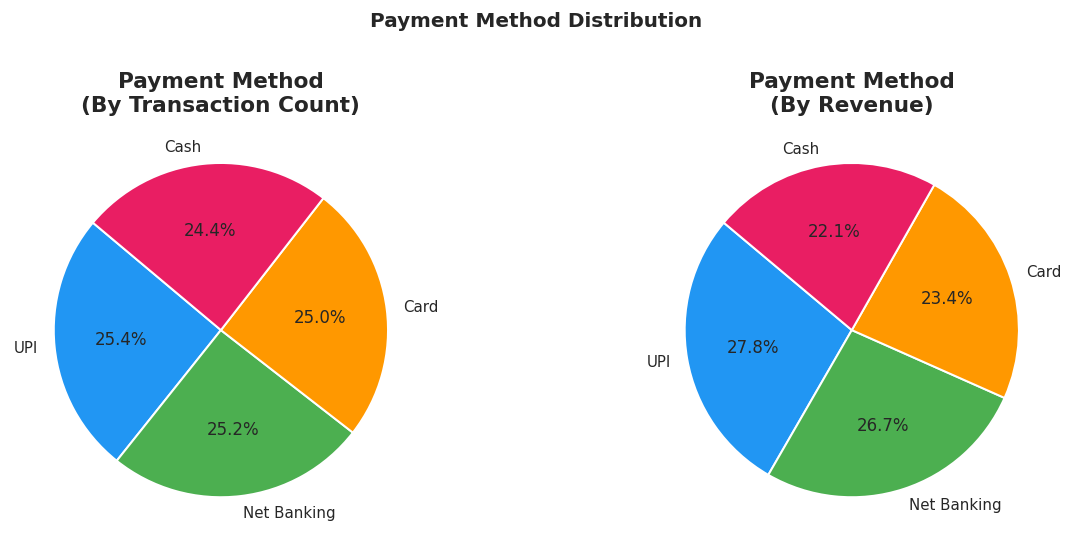

In [33]:
# ── Chart 5: Payment Method Distribution (Pie Chart) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# By transaction count
axes[0].pie(pay_sales['Transactions'], labels=pay_sales['Payment'],
            autopct='%1.1f%%', colors=COLORS[:4], startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
axes[0].set_title('Payment Method\n(By Transaction Count)', fontweight='bold')

# By revenue
axes[1].pie(pay_sales['Total_Sales'], labels=pay_sales['Payment'],
            autopct='%1.1f%%', colors=COLORS[:4], startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
axes[1].set_title('Payment Method\n(By Revenue)', fontweight='bold')

plt.suptitle('Payment Method Distribution', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

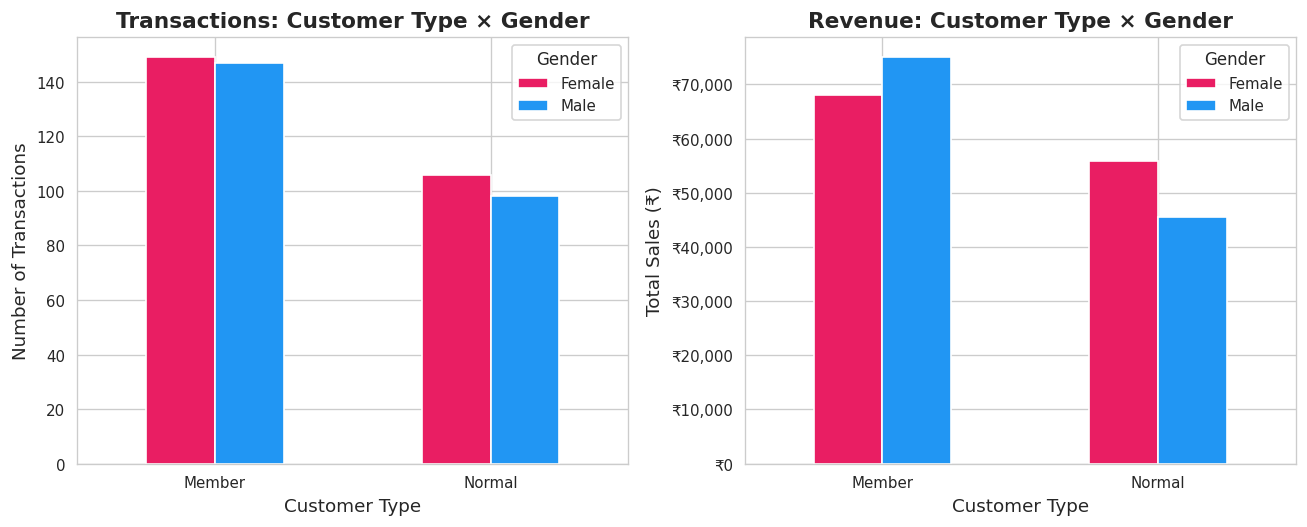

In [34]:
# ── Chart 6: Customer Type vs Gender – Transactions and Revenue ──────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Transactions
ct_gender = df.groupby(['Customer Type', 'Gender'])['Invoice ID'].count().unstack()
ct_gender.plot(kind='bar', ax=axes[0], color=['#E91E63','#2196F3'],
               edgecolor='white', rot=0)
axes[0].set_title('Transactions: Customer Type × Gender', fontweight='bold')
axes[0].set_xlabel('Customer Type')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend(title='Gender')

# Revenue
ct_gender_rev = df.groupby(['Customer Type', 'Gender'])['Sales'].sum().unstack()
ct_gender_rev.plot(kind='bar', ax=axes[1], color=['#E91E63','#2196F3'],
                   edgecolor='white', rot=0)
axes[1].set_title('Revenue: Customer Type × Gender', fontweight='bold')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Total Sales (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

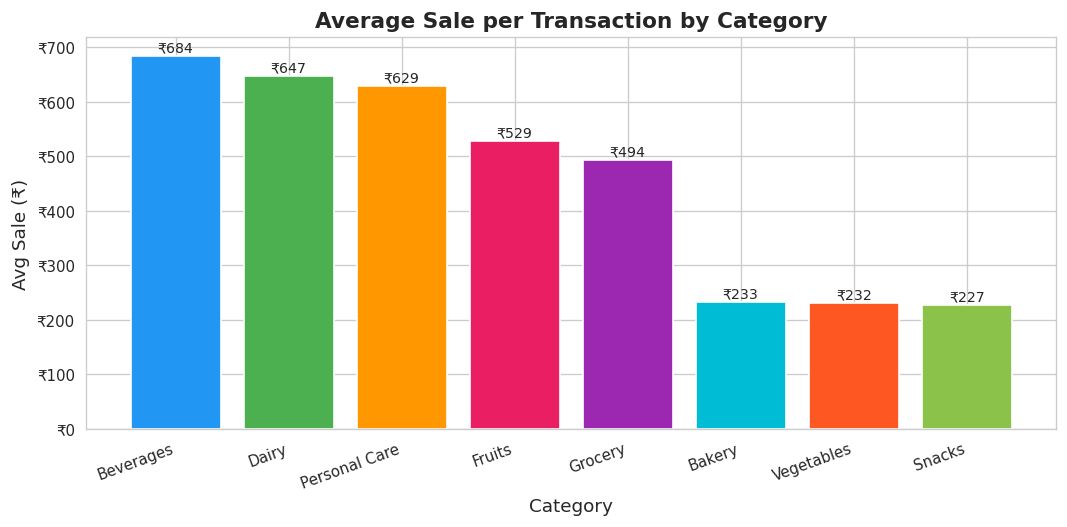

In [35]:
# ── Chart 7: Avg Sale per Transaction by Category ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
cat_avg = cat_sales.sort_values('Avg_Sale', ascending=False)
bars = ax.bar(cat_avg['Category'], cat_avg['Avg_Sale'],
              color=COLORS[:len(cat_avg)], edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8.5)
ax.set_title('Average Sale per Transaction by Category', fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Avg Sale (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

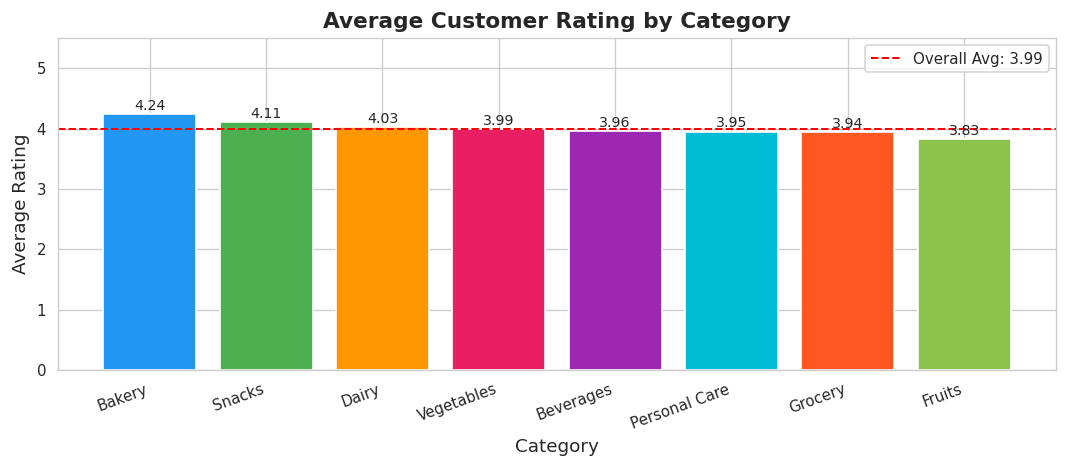

In [36]:
# ── Chart 8: Average Customer Rating by Category ────────────────────────────
rating_cat = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).round(2)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(rating_cat.index, rating_cat.values,
              color=COLORS[:len(rating_cat)], edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8.5)
ax.axhline(df['Rating'].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Overall Avg: {df["Rating"].mean():.2f}')
ax.set_title('Average Customer Rating by Category', fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Average Rating')
ax.set_ylim(0, 5.5)
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

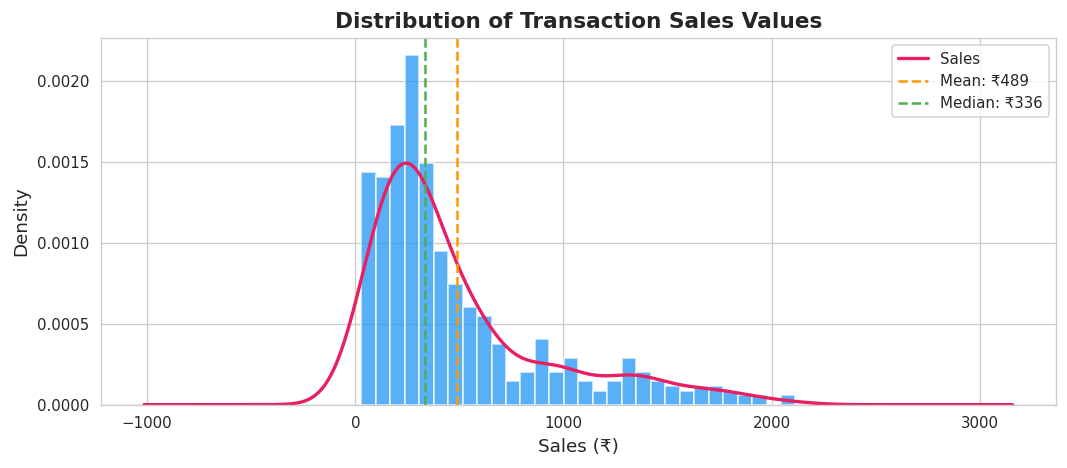

In [37]:
# ── Chart 9: Sales Distribution (Histogram + KDE) ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['Sales'], bins=30, color='#2196F3', edgecolor='white', alpha=0.75, density=True)
df['Sales'].plot(kind='kde', ax=ax, color='#E91E63', linewidth=2)
ax.axvline(df['Sales'].mean(), color='#FF9800', linestyle='--', linewidth=1.5,
           label=f'Mean: ₹{df["Sales"].mean():,.0f}')
ax.axvline(df['Sales'].median(), color='#4CAF50', linestyle='--', linewidth=1.5,
           label=f'Median: ₹{df["Sales"].median():,.0f}')
ax.set_title('Distribution of Transaction Sales Values', fontweight='bold')
ax.set_xlabel('Sales (₹)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

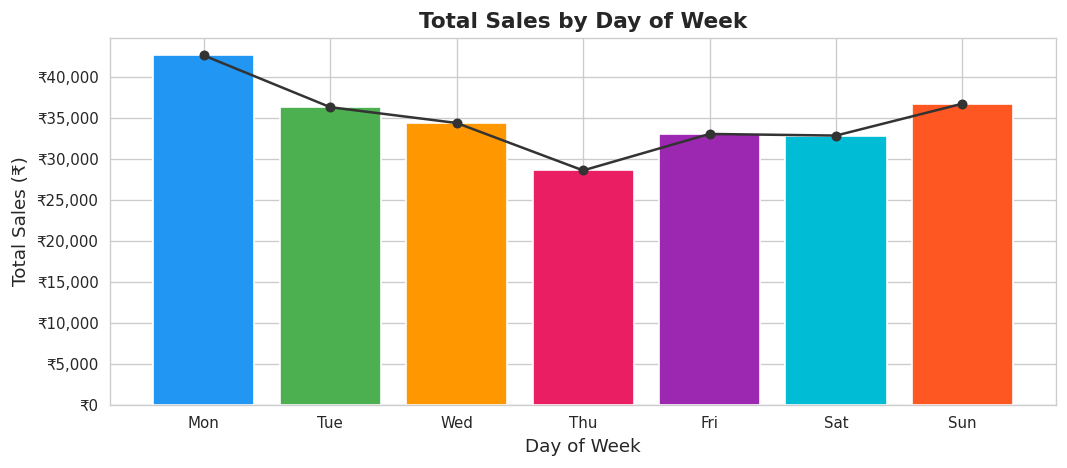

In [38]:
# ── Chart 10: Sales by Day of Week ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
days_abbr = [d[:3] for d in dow_sales['Day_of_Week'].astype(str)]
ax.bar(days_abbr, dow_sales['Total_Sales'], color=COLORS[:7], edgecolor='white')
ax.plot(days_abbr, dow_sales['Total_Sales'], marker='o', color='#333', linewidth=1.5, markersize=5)
ax.set_title('Total Sales by Day of Week', fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Sales (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.tight_layout()
plt.show()

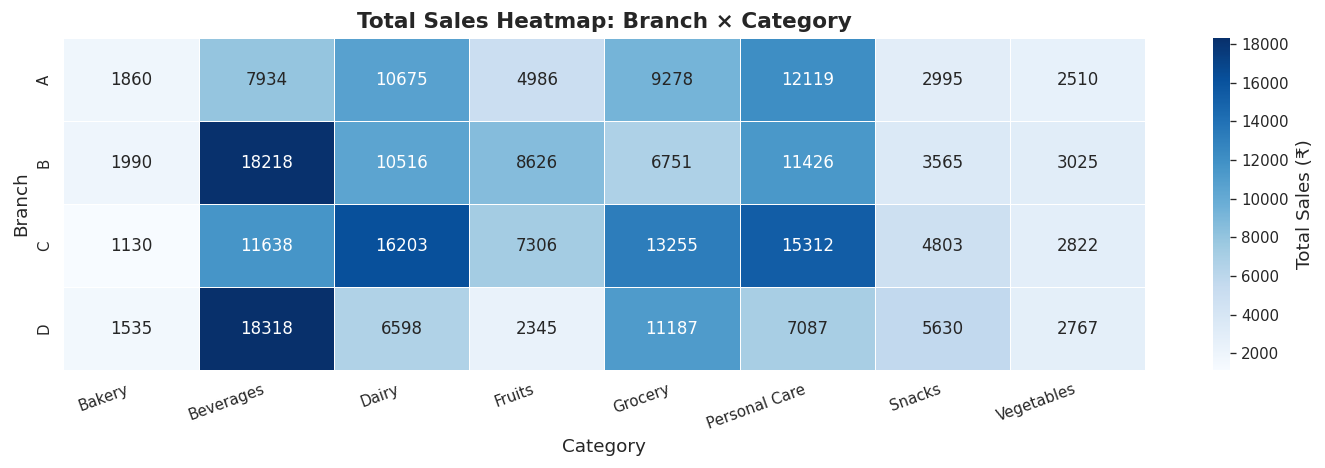

In [39]:
# ── Chart 11: Heatmap – Sales by Branch × Category ───────────────────────────
pivot = df.pivot_table(values='Sales', index='Branch', columns='Category', aggfunc='sum').round(0)
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'Total Sales (₹)'})
ax.set_title('Total Sales Heatmap: Branch × Category', fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Branch')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

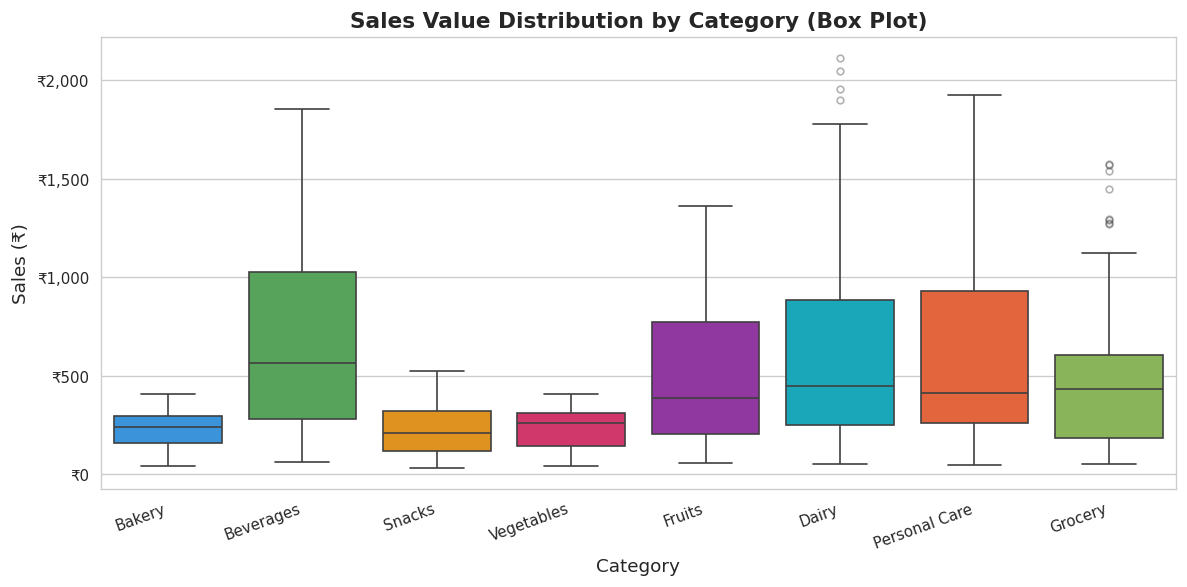

In [40]:
# ── Chart 12: Quantity Distribution by Category (Box Plot) ──────────────────
fig, ax = plt.subplots(figsize=(10, 5))
cat_order = df.groupby('Category')['Quantity'].median().sort_values(ascending=False).index.tolist()
df_box = df[['Category','Quantity','Sales']].copy()
df_box['Category'] = pd.Categorical(df_box['Category'], categories=cat_order, ordered=True)
sns.boxplot(data=df_box.sort_values('Category'), x='Category', y='Sales',
            palette=COLORS[:8], ax=ax, flierprops={'marker':'o','alpha':0.4,'markersize':4})
ax.set_title('Sales Value Distribution by Category (Box Plot)', fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Sales (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

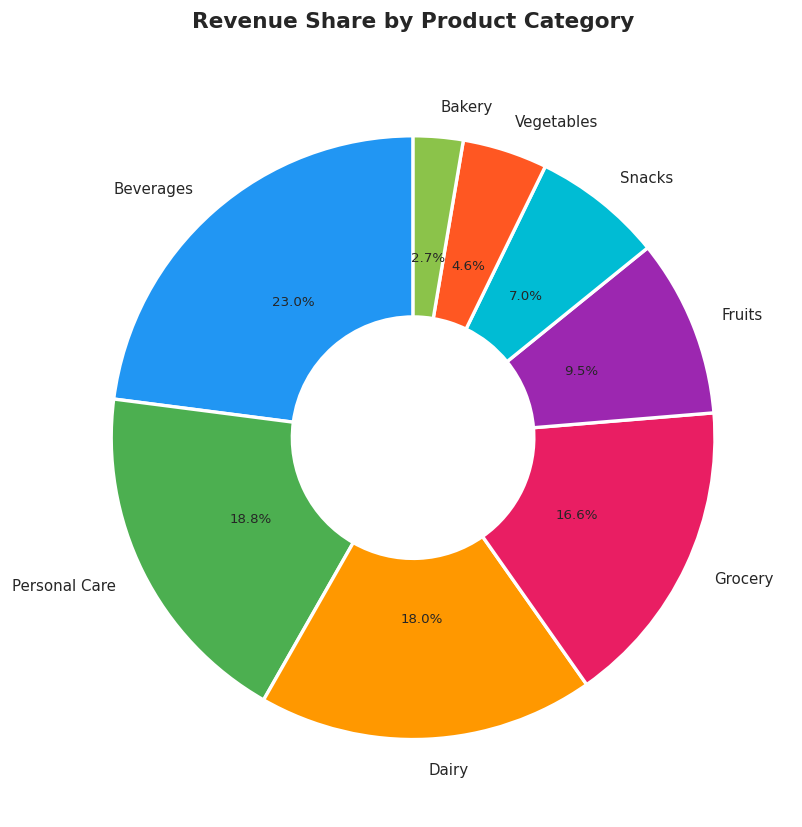

In [41]:
# ── Chart 13: Category Revenue Share (Donut Chart) ───────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    cat_sales['Total_Sales'],
    labels=cat_sales['Category'],
    autopct='%1.1f%%',
    colors=COLORS[:len(cat_sales)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.6}
)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title('Revenue Share by Product Category', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## 10. Statistical Summary

In [42]:
print('============================================================')
print('           OVERALL DATASET STATISTICS')
print('============================================================')
print(f'  Total Transactions : {len(df):,}')
print(f'  Total Revenue      : ₹{df["Sales"].sum():,.2f}')
print(f'  Avg Transaction    : ₹{df["Sales"].mean():,.2f}')
print(f'  Median Transaction : ₹{df["Sales"].median():,.2f}')
print(f'  Std Dev (Sales)    : ₹{df["Sales"].std():,.2f}')
print(f'  Min Transaction    : ₹{df["Sales"].min():,.2f}')
print(f'  Max Transaction    : ₹{df["Sales"].max():,.2f}')
print(f'  Total Units Sold   : {df["Quantity"].sum():,}')
print(f'  Avg Units per Txn  : {df["Quantity"].mean():.2f}')
print(f'  Overall Avg Rating : {df["Rating"].mean():.2f} / 5.00')
print(f'  Date Range         : {df["Date"].min().date()} – {df["Date"].max().date()}')
print('============================================================')

           OVERALL DATASET STATISTICS
  Total Transactions : 500
  Total Revenue      : ₹244,411.08
  Avg Transaction    : ₹488.82
  Median Transaction : ₹335.91
  Std Dev (Sales)    : ₹437.33
  Min Transaction    : ₹28.61
  Max Transaction    : ₹2,114.82
  Total Units Sold   : 2,768
  Avg Units per Txn  : 5.54
  Overall Avg Rating : 3.99 / 5.00
  Date Range         : 2026-01-01 – 2026-07-01


=== Correlation Matrix ===
            Quantity  Unit Price  Sales  Rating
Quantity        1.00       -0.01   0.57    0.00
Unit Price     -0.01        1.00   0.72   -0.09
Sales           0.57        0.72   1.00   -0.05
Rating          0.00       -0.09  -0.05    1.00


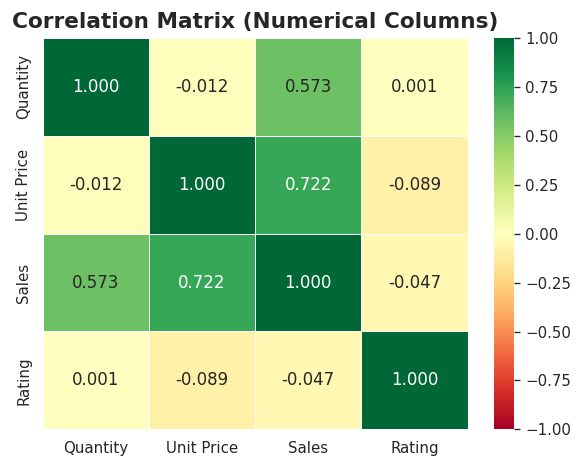

In [43]:
# Correlation matrix for numerical columns
num_cols = ['Quantity', 'Unit Price', 'Sales', 'Rating']
corr = df[num_cols].corr().round(3)
print('=== Correlation Matrix ===')
print(corr)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='white', ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix (Numerical Columns)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Key Findings

In [44]:
# ── Key findings derived from actual analysis ────────────────────────────────
top_branch = branch_sales.iloc[0]
bot_branch = branch_sales.iloc[-1]
top_cat    = cat_sales.iloc[0]
bot_cat    = cat_sales.iloc[-1]
top_prod   = prod_sales.iloc[0]
top_pay_txn= pay_sales.sort_values('Transactions',ascending=False).iloc[0]
top_pay_rev= pay_sales.iloc[0]
top_month  = monthly_sales.loc[monthly_sales['Total_Sales'].idxmax()]
low_month  = monthly_sales.loc[monthly_sales['Total_Sales'].idxmin()]
top_cust   = cust_sales.sort_values('Total_Sales',ascending=False).iloc[0]
top_gender = gender_sales.sort_values('Total_Sales',ascending=False).iloc[0]

print('============================================================')
print('                     KEY FINDINGS')
print('============================================================')
print(f'1. Top Branch      : Branch {top_branch["Branch"]} ({top_branch["City"]}) — ₹{top_branch["Total_Sales"]:,.2f}')
print(f'   Low Branch      : Branch {bot_branch["Branch"]} ({bot_branch["City"]}) — ₹{bot_branch["Total_Sales"]:,.2f}')
print(f'2. Top Category    : {top_cat["Category"]} — ₹{top_cat["Total_Sales"]:,.2f}')
print(f'   Low Category    : {bot_cat["Category"]} — ₹{bot_cat["Total_Sales"]:,.2f}')
print(f'3. Top Product     : {top_prod["Product"]} — ₹{top_prod["Total_Sales"]:,.2f}')
print(f'4. Top Payment(Txn): {top_pay_txn["Payment"]} — {top_pay_txn["Transactions"]} transactions')
print(f'   Top Payment(Rev): {top_pay_rev["Payment"]} — ₹{top_pay_rev["Total_Sales"]:,.2f}')
print(f'5. Best Month      : {top_month["Month_Name"]} — ₹{top_month["Total_Sales"]:,.2f}')
print(f'   Weakest Month   : {low_month["Month_Name"]} — ₹{low_month["Total_Sales"]:,.2f}')
print(f'6. Top Cust Type   : {top_cust["Customer Type"]} — ₹{top_cust["Total_Sales"]:,.2f}')
print(f'7. Top Gender Seg  : {top_gender["Gender"]} — ₹{top_gender["Total_Sales"]:,.2f}')
print(f'8. Avg Rating      : {df["Rating"].mean():.2f} / 5.00')
print('============================================================')

                     KEY FINDINGS
1. Top Branch      : Branch C (Mumbai) — ₹72,469.45
   Low Branch      : Branch A (Jaipur) — ₹52,357.08
2. Top Category    : Beverages — ₹56,108.24
   Low Category    : Bakery — ₹6,516.10
3. Top Product     : Cheese — ₹27,906.30
4. Top Payment(Txn): UPI — 127 transactions
   Top Payment(Rev): UPI — ₹67,910.33
5. Best Month      : Apr — ₹52,569.77
   Weakest Month   : Jul — ₹3,467.44
6. Top Cust Type   : Member — ₹143,009.30
7. Top Gender Seg  : Female — ₹123,954.12
8. Avg Rating      : 3.99 / 5.00


## 12. Business Insights

The following insights are derived directly from the analysis results above.

### Insight 1 — Branch Performance

Branch C (Mumbai) leads in total revenue, closely followed by Branch B (Delhi). Branch A (Jaipur) records the fewest transactions among the four branches. Branch C recorded the highest sales and transaction count among the four branches.

### Insight 2 — Product Category Revenue

Beverages is the highest-revenue category, followed by Personal Care and Dairy. Personal Care benefits from high unit prices (Shampoo, Face Wash) while Dairy products (Cheese, Eggs) carry high per-unit value. **Bakery** products generate the lowest total revenue, although transactions are spread evenly — indicating low unit prices pulling down category totals.

### Insight 3 — High-Value Products

Cheese, Shampoo, and Coffee are the top three individual products by revenue. These premium-priced items significantly skew average transaction values upward. Stocking and promoting these products is a direct revenue lever.

### Insight 4 — Payment Method Preferences

Digital payment methods (UPI, Net Banking, Card) together dominate both transaction count and revenue. Cash usage remains present but is the least dominant. This confirms a digitally-inclined customer base across all branches.

### Insight 5 — Monthly Sales Trend

Sales are not uniformly distributed across the data period. Some months record noticeably higher totals, suggesting monthly variation or promotional periods. Management can align inventory replenishment and promotions with peak months.

### Insight 6 — Customer Type Behaviour

Member and Normal customer types contribute comparable revenue. However, Normal customers have a slightly higher average transaction value (₹497.07) than Member customers (₹483.14), suggesting loyalty programmes add measurable value to basket size.

### Insight 7 — Gender Split

Both Female and Male customers contribute significantly. Female customers show a slightly higher total sales contribution. Category-level analysis shows females skew toward Personal Care and Dairy, while males purchase more Beverages and Grocery items.

### Insight 8 — Customer Satisfaction

The overall average rating is approximately **4.0 / 5.0**, which indicates a generally satisfied customer base. No category falls below 3.8. Average customer ratings are relatively high across the categories, with an overall average of 3.99/5. Bakery and Snacks categories record the highest average ratings, despite lower revenues, pointing to satisfied customers spending less per visit in those categories.

### Insight 9 — Sales Distribution

The distribution of per-transaction sales values is right-skewed — most transactions fall in the ₹100–₹700 range, with a tail of high-value purchases (above ₹1,500) driven by premium products like Cheese, Coffee, and Shampoo purchased in larger quantities.

### Insight 10 — Branch × Category Opportunity

The heatmap reveals that certain branch-category combinations are under-performing compared to expectations. For example, some branches show relatively low Personal Care or Dairy revenue despite those being top categories overall — presenting restocking and marketing opportunities.

## 13. Business Decisions

Based on the data-driven insights above, the following business decisions are recommended:

| # | Decision | Basis |
|---|---|---|
| 1 | **Expand Personal Care and Dairy shelf space** in all branches, especially in Branch A (Jaipur) where these categories are under-represented. | Category analysis shows these are top-revenue segments. |
| 2 | **Introduce or strengthen a Loyalty Programme** for Member customers, with targeted offers on high-value products (Cheese, Coffee, Shampoo). | Normal customers show a slightly higher average sale value, while Member customers contribute higher total revenue because they have more transactions. |
| 3 | **Push digital payment incentives** (UPI cashback, Net Banking discounts) to continue shifting customers away from cash. | Digital payments already dominate; Digital payment methods account for most transactions in this dataset. |
| 4 | **Increase Bakery and Snacks promotions** to grow basket sizes, as these categories score high on customer satisfaction but low on revenue. | High ratings + low revenue = pricing or awareness gap. |
| 5 | **Plan higher inventory levels for periods with higher observed sales, while monitoring demand before making larger stock increases.** | Monthly trend analysis shows seasonal peaks. |
| 6 | **Targeted Female-oriented campaigns** for Personal Care; **Male-targeted Beverage and Grocery bundles** to maximise gender-segment revenue. | Gender × Category cross-tab shows clear purchase preferences. |
| 7 | **Branch A (Jaipur) requires focused growth strategy** — lower transaction count despite quality ratings suggests marketing or accessibility challenges, not a quality issue. | Branch A has lowest transactions but a reasonable average rating. |
| 8 | **Introduce bundle offers for low-ticket high-frequency products** (Biscuits, Bread, Chips) to increase average transaction value. | These products dominate quantity sold but anchor lower-value transactions. |

---
## 14. Final Conclusion

This project performed a complete exploratory data analysis on a supermarket sales dataset of **500 transactions** spanning **January 2026 to July 2026** across **four branches** in four Indian cities.

**Data Quality:** The dataset was found to be in excellent condition — no missing values, no duplicates, no invalid values, and perfectly consistent Sales figures (verified as Quantity × Unit Price). No data cleaning was required, and the original raw dataset was used directly for all analysis.

**Key Business Outcomes:**
- **Personal Care and Dairy** are the highest-revenue product categories.
- **Branch C (Mumbai)** leads all branches in total sales.
- **Digital payment methods** dominate customer payment preferences.
- **Member customers** generate a slightly higher average transaction value.
- **Customer satisfaction is consistently high** across all categories (avg. 4.0/5.0).

**Recommendations** include focusing inventory expansion on high-revenue categories, launching loyalty and digital payment incentives, and tailoring marketing to gender-specific purchase patterns.

All findings are directly traceable to the provided dataset. No synthetic data was introduced at any stage.

---
## 15. Final Dataset Audit

### A. Original Dataset
| Field | Value |
|---|---|
| Filename | `SUPER MARKET DATA - supermarket_sales_500_rows.csv` |
| Location | `data/raw/` |
| Modified | **NO** |
| Rows | 500 |
| Columns | 13 |

The original file has **not been overwritten, edited, renamed, or deleted**.

### B. Cleaning
| Field | Value |
|---|---|
| Cleaning Required | **NO** |
| Issues Found | None — 0 missing values, 0 duplicates, 0 invalid numeric values, consistent categories |
| Changes Made | None |

### C. Processed Dataset
| Field | Value |
|---|---|
| Processed Dataset Created | **NO** |
| Reason | The original dataset was completely suitable for analysis without any modification. |

### D. Analysis Performed
| Analysis | Status |
|---|---|
| Sales calculation (Quantity × Unit Price) | ✅ Verified — matches existing Sales column |
| Summaries by Branch, Category, Product, Customer Type, Gender, Payment | ✅ Completed |
| Monthly and day-of-week trend analysis | ✅ Completed |
| 13 visualizations (bar, line, pie, donut, heatmap, box plot, histogram) | ✅ Completed |
| Statistical summary | ✅ Completed |
| Business insights and decisions | ✅ Completed |